# 05a – Gradient boosting: NYC Citi Bike

**Worked on by:** Andreas Schellekens (feature experiments, hyperparameter search with yearly folds, evaluation, deployable model)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant), based on `03_model_baseline.ipynb` and `04_model_automl.ipynb`. All steps were reviewed by the team; we must be able to explain every cell ourselves.

## 1. Goal and setup

04 showed that boosting is the best model family for daily demand, and that tree models profit from the extra weather columns of 02. This notebook builds a **tuned gradient boosting model by hand**, following the protocol of 03 (section 3), and tests the ideas that 03 and 04 left open: separate flags for the big holidays, a feature for the recent growth of the system, and more weight for recent training years.

**Why scikit-learn's `HistGradientBoostingRegressor`** and not the gradient boosting or LightGBM of 04:

- it handles **missing values natively** (the wind gaps, 02 section 4): at every split it learns on which side the missing values go, so no imputation step is needed;
- it handles **categorical features natively** (weekday, month): it can group, for example, Saturday and Sunday in one split, without one-hot columns;
- it is fast (histogram-based, like LightGBM) and its model file is small, and it needs only scikit-learn in the API (LightGBM conflicts with PyCaret on Windows, 04 section 1).

Setup: imports, the chart style of the Citi Bike notebooks, the dataset description of 02, and the protocol helpers of 03 (`yearly_folds`, `trips_mape` / `mape_scorer`, `evaluate`), copied so this notebook runs on its own.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import json
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import loguniform, randint, uniform
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from sklearn.model_selection import RandomizedSearchCV, cross_val_score

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": INK_SECONDARY, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY, "axes.titlesize": 12, "axes.titleweight": "bold",
})
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

NOTEBOOK = "05a_model_gradient_boosting"
RANDOM_STATE = 42
MODEL_DIR = Path("models")
MODEL_PATH = MODEL_DIR / "citibike_gradient_boosting.joblib"
METRICS_PATH = MODEL_DIR / "metrics.csv"
CV_YEARS = [2016, 2017, 2018, 2019, 2022, 2023]
with open(MODEL_DIR / "citibike_daily_dataset.json", encoding="utf-8") as file:
    DATASET = json.load(file)


def load(split):
    return pd.read_csv(DATASET["files"][split], index_col="date", parse_dates=["date"])


def yearly_folds(index, years=CV_YEARS):
    positions = np.arange(len(index))
    return [(positions[index.year < year], positions[index.year == year]) for year in years]


def trips_mape(actual_log_ratio, predicted_log_ratio):
    return np.mean(np.abs(np.expm1(predicted_log_ratio - actual_log_ratio))) * 100


mape_scorer = make_scorer(trips_mape, greater_is_better=False)


def evaluate(name, split, actual, predicted):
    error = predicted - actual
    has_trips = actual > 0
    percentage = error[has_trips] / actual[has_trips] * 100
    return {
        "model": name, "notebook": NOTEBOOK, "split": split, "days": len(actual),
        "mae": error.abs().mean(), "rmse": np.sqrt((error ** 2).mean()),
        "mape": percentage.abs().mean(), "median_ape": percentage.abs().median(),
        "within_20pct": (percentage.abs() <= 20).mean() * 100, "bias_pct": percentage.mean(),
    }


train, validation, test = load("train"), load("validation"), load("test")
fit_days = train[train.total > 0]
folds = yearly_folds(fit_days.index)
print(f"training days with trips: {len(fit_days):,}; {len(folds)} yearly folds; validation {len(validation)} days")

training days with trips: 3,462; 6 yearly folds; validation 366 days


## 2. Which features? Experiments on the folds

All experiments use the gradient boosting model with its **default settings**, so that only the features change, and are scored with the protocol: the MAPE in trips on the yearly folds (`mape_scorer`), then checked on the validation year. The feature sets:

1. **baseline inputs:** the seven inputs of 03 (with the precipitation class as a number 0-4 and the snow flag);
2. **extended:** the calendar plus all weather columns of 02 as numbers: maximum and minimum temperature, precipitation, snowfall and snow depth in mm, wind, and the day of the year. The precipitation class and the snow flag are left out: they are coarse versions of the millimetres, and a tree can find its own thresholds;
3. extended + the four **big-holiday flags** that 02 added after the baseline's error analysis (Thanksgiving, the day after, Christmas Day, New Year's Day);
4. extended + **recent growth**: the trips per day of the last three published months (*m-4* to *m-2*) divided by the same three months a year earlier, as a logarithm. 03 and 04 found that the models drift when growth changes; this feature tells the model how fast the system is growing right now. It is computed from `Data/citibike_monthly.csv`, so it uses only published months;
5. extended with **more weight for recent years**: every training day gets the weight 0.5^(age in years / 3), so a day three years older than the newest training day counts half. If the behaviour of riders changes over time, recent years should be more informative.

`weekday` and `month` are passed as categorical features.

In [2]:
CALENDAR = ["weekday", "month", "holiday", "christmas_week"]
EXTENDED = CALENDAR + ["day_of_year", "tmax_c", "tmin_c", "precipitation_mm", "snowfall_mm", "snow_depth_mm", "wind_ms"]
BIG_HOLIDAYS = ["thanksgiving", "day_after_thanksgiving", "christmas_day", "new_years_day"]
PRECIPITATION_CODES = {"dry": 0, "light": 1, "moderate": 2, "heavy": 3, "very heavy": 4}

monthly = pd.read_csv(DATASET["files"]["monthly"], index_col="month", parse_dates=["month"])
trips_per_day_3m = monthly.total.rolling(3).sum() / monthly.days.rolling(3).sum()
growth_by_month = np.log(trips_per_day_3m / trips_per_day_3m.shift(12)).shift(2)  # month m: (m-4..m-2) / a year earlier


def add_columns(days):
    days = days.copy()
    days["precipitation_class"] = days.precipitation.map(PRECIPITATION_CODES)
    days["recent_growth"] = growth_by_month.reindex(days.index.to_period("M").to_timestamp()).to_numpy()
    return days


fit_days, validation, test = add_columns(fit_days), add_columns(validation), add_columns(test)
y_fit = np.log(fit_days.demand_ratio)


def recency_weights(index, half_life_years=3):
    age_years = (index.max() - index).days / 365.25
    return 0.5 ** (age_years / half_life_years)


def gradient_boosting(**params):
    return HistGradientBoostingRegressor(categorical_features=["weekday", "month"], random_state=RANDOM_STATE, **params)


def fold_scores(columns, weighted=False, model=None):
    """MAPE in trips per fold; recency weights are computed inside every fold from its own fit days."""
    scores = []
    for fit_positions, predict_positions in folds:
        estimator = model if model is not None else gradient_boosting()
        fit_part = fit_days.iloc[fit_positions]
        weights = recency_weights(fit_part.index) if weighted else None
        estimator.fit(fit_part[columns], y_fit.iloc[fit_positions], sample_weight=weights)
        predicted = estimator.predict(fit_days.iloc[predict_positions][columns])
        scores.append(trips_mape(y_fit.iloc[predict_positions], predicted))
    return scores


def validation_score(columns, weighted=False, model=None):
    estimator = model if model is not None else gradient_boosting()
    weights = recency_weights(fit_days.index) if weighted else None
    estimator.fit(fit_days[columns], y_fit, sample_weight=weights)
    return evaluate("", "validation", validation.total,
                    pd.Series(np.exp(estimator.predict(validation[columns])) * validation.level_12m, index=validation.index))


EXPERIMENTS = {
    "1 baseline inputs": (CALENDAR + ["tmax_c", "precipitation_class", "snow_on_ground"], False),
    "2 extended": (EXTENDED, False),
    "3 extended + big holidays": (EXTENDED + BIG_HOLIDAYS, False),
    "4 extended + recent growth": (EXTENDED + ["recent_growth"], False),
    "5 extended, recent years weighted": (EXTENDED, True),
}
rows = []
for name, (columns, weighted) in EXPERIMENTS.items():
    scores = fold_scores(columns, weighted)
    check = validation_score(columns, weighted)
    rows.append({"features": name, **{str(year): score for year, score in zip(CV_YEARS, scores)},
                 "folds mean": np.mean(scores), "validation MAPE": check["mape"], "validation bias": check["bias_pct"]})
experiments = pd.DataFrame(rows).set_index("features")
print(f"recent growth is missing for the first {fit_days.recent_growth.isna().sum()} training days "
      f"(the model handles them as missing values)")
chosen_set = experiments["folds mean"].idxmin()  # protocol: the choice is made on the folds
print("chosen on the folds:", chosen_set)
experiments.round(2)

recent growth is missing for the first 92 training days (the model handles them as missing values)
chosen on the folds: 2 extended


,2016,2017,2018,2019,2022,2023,folds mean,validation MAPE,validation bias
features,,,,,,,,,
1 baseline inputs,20.13,19.70,17.98,14.10,15.06,12.53,16.58,11.75,-4.17
2 extended,18.44,20.07,17.14,11.65,13.84,11.17,15.39,10.05,-3.21
3 extended + big holidays,18.44,20.07,17.14,11.65,13.84,11.17,15.39,10.05,-3.21
4 extended + recent growth,17.80,22.32,18.21,13.59,16.57,11.48,16.66,10.18,-3.21
"5 extended, recent years weighted",18.54,20.09,17.25,11.36,14.01,11.27,15.42,9.63,-3.41


**Interpretation**

- **The extended columns help clearly** (experiment 2 against 1): fold MAPE 15.39% against 16.58%, validation 10.05% against 11.75%. This confirms 04: the trees use the millimetres of rain and snow, the minimum temperature and the day of the year.
- **The big-holiday flags change nothing at all** (experiment 3 gives exactly the same numbers as 2). The trees never split on them: a leaf needs at least 20 days by default, and the training period has only 9 or 10 of each of these holidays (one a year). A linear model can use such rare flags (one coefficient each); they stay in the dataset for the linear model of 05b.
- **Recent growth makes the model worse** (16.66% against 15.39%), most of all in the 2017 and 2022 folds. Three months against the same three months a year earlier also move with the weather (a snowy February) and with COVID-19 in 2020-2021, so the trees split on noise. The attempt to fix the drift of 03/04 with this feature fails inside the training period, so it is not adopted.
- **Weighting recent years:** equal on the folds (15.42% against 15.39%) and better on the validation year (9.63% against 10.05%). Following the protocol the choice is made on the folds, where it makes no difference, so it is not adopted. Choosing it because of the validation year alone would turn the validation year into a tuning signal, and then it could no longer judge the result honestly.

**Decision:** the extended feature set (experiment 2), without weights.

## 3. Tuning the hyperparameters

A random search over 40 combinations, scored with the MAPE in trips on the yearly folds (`mape_scorer`, 03 section 3). The search space:

| Hyperparameter | Range | What it does |
|---|---|---|
| `learning_rate` | 0.01-0.3 (log scale) | how much every new tree corrects the previous ones; small = slow but careful |
| `max_iter` | 100-800 | number of trees |
| `max_leaf_nodes` | 8-63 | size (complexity) of every tree |
| `min_samples_leaf` | 5-59 | a leaf needs at least this many days: protects against fitting single odd days |
| `l2_regularization` | 0.001-10 (log scale) | shrinks the leaf values |
| `max_features` | 0.4-1.0 | share of the columns every split may consider (randomness, as in a forest) |

**A lesson from the first version of this notebook:** the search was first scored with the MAE on the log scale (the protocol's first choice). It picked a slow model (learning rate 0.013, 140 trees) that was better on the log scale but **worse in trips** than the default (fold MAPE 16.4% against 15.4%, validation 12.2% against 10.1%). A search optimises exactly what it is told; that is why the protocol now uses the MAPE in trips (03 section 3).

In [3]:
FEATURES, WEIGHTED = EXPERIMENTS[chosen_set]
assert not WEIGHTED, "the search below fits without weights"
SEARCH_SPACE = {
    "learning_rate": loguniform(0.01, 0.3), "max_iter": randint(100, 800), "max_leaf_nodes": randint(8, 64),
    "min_samples_leaf": randint(5, 60), "l2_regularization": loguniform(1e-3, 10), "max_features": uniform(0.4, 0.6),
}
start = time.time()
search = RandomizedSearchCV(gradient_boosting(), SEARCH_SPACE, n_iter=40, scoring=mape_scorer, cv=folds,
                            random_state=RANDOM_STATE, n_jobs=1)
search.fit(fit_days[FEATURES], y_fit)
print(f"search took {time.time() - start:.0f} s")
default_folds = -cross_val_score(gradient_boosting(), fit_days[FEATURES], y_fit, cv=folds, scoring=mape_scorer).mean()
print(f"default settings: fold MAPE {default_folds:.2f}%; best of the search: {-search.best_score_:.2f}%")
top = pd.DataFrame(search.cv_results_).sort_values("rank_test_score").head(5)
top = top[["mean_test_score", "std_test_score"] + [f"param_{name}" for name in SEARCH_SPACE]]
top["mean_test_score"] = -top.mean_test_score
top.rename(columns=lambda column: column.replace("param_", "")).round(3)

search took 344 s
default settings: fold MAPE 15.39%; best of the search: 15.21%


,mean_test_score,std_test_score,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,max_features
32,15.210,3.417,0.035158,393,31,9,0.002106,0.545296
38,15.245,3.151,0.060584,403,19,9,0.166266,0.545111
1,15.268,3.274,0.047683,763,10,26,0.002511,0.600225
20,15.310,3.223,0.087107,195,11,34,0.001336,0.588614
34,15.469,2.987,0.018859,759,43,23,0.019192,0.424465


**Interpretation**

- The best combination reaches a fold MAPE of 15.21% against 15.39% for the default settings: a gain of 0.18 points, far smaller than the spread between the folds (standard deviation about 3.4 points). The default settings were already close to optimal, as with the mushrooms (05b there).
- The top five differ a lot in learning rate (0.035-0.087), number of trees and tree size (10-31 leaves), so many combinations work about equally well. The one thing they share is `max_features` of about 0.55: letting every split see only half of the columns adds randomness, which helps a little against overfitting.
- The best settings: learning rate 0.035, 393 trees, at most 31 leaves, at least 9 days per leaf, almost no L2 penalty, 55% of the columns per split.

Default or tuned? Both are fitted on all training days and scored on the validation year.

In [4]:
candidates = {"default": gradient_boosting(), "tuned": gradient_boosting(**search.best_params_)}
rows = []
for name, model in candidates.items():
    check = validation_score(FEATURES, model=model)
    folds_mape = default_folds if name == "default" else -search.best_score_
    rows.append({"model": name, "folds MAPE": folds_mape, "validation MAE": check["mae"],
                 "validation MAPE": check["mape"], "validation within 20%": check["within_20pct"],
                 "validation bias": check["bias_pct"]})
chosen_settings = "tuned" if -search.best_score_ < default_folds else "default"  # protocol: decided on the folds
print("chosen on the folds:", chosen_settings)
pd.DataFrame(rows).set_index("model").round(2)

chosen on the folds: tuned


,folds MAPE,validation MAE,validation MAPE,validation within 20%,validation bias
model,,,,,
default,15.39,9879.25,10.05,85.52,-3.21
tuned,15.21,9499.55,9.64,86.07,-3.10


The tuned model is better on the folds (15.21% against 15.39%) and the validation year agrees (MAPE 9.64% against 10.05%, MAE 9,500 against 9,879 trips). **Decision: the tuned model.** The gain is small; the main value of the search is knowing that the default settings were not leaving much on the table.

## 4. Final fit, validation and test

The chosen model is fitted on all training days with trips and evaluated on the validation year and **once** on the test period. For comparison: the baseline (03) and PyCaret's blend (04), read from `models/metrics.csv`.

In [5]:
model = clone(candidates[chosen_settings])
model.fit(fit_days[FEATURES], y_fit)


def predict_trips(days):
    return pd.Series(np.exp(model.predict(days[FEATURES])) * days.level_12m, index=days.index)


predictions = {"validation": predict_trips(validation), "test": predict_trips(test)}
results = [evaluate("gradient boosting (05a)", split, days.total, predictions[split])
           for split, days in [("validation", validation), ("test", test)]]
earlier = pd.read_csv(METRICS_PATH)
earlier = earlier[earlier.notebook.isin(["03_model_baseline", "04_model_automl"]) & ~earlier.model.str.contains("naive")]
pd.concat([earlier, pd.DataFrame(results)]).drop(columns="notebook").set_index(["split", "model"]).sort_index(
    level="split", sort_remaining=False).round(1)

days      mae     rmse  mape  median_ape  within_20pct  bias_pct
split      model                                                                                              
test       linear regression (baseline)        607  17205.6  22336.1  17.4        11.9          73.6       7.8
           PyCaret blend gbr + rf + lightgbm   607  13806.2  17529.1  14.6         9.8          80.9       8.6
           gradient boosting (05a)             607  14577.8  18235.1  15.1        10.4          80.0       8.8
validation linear regression (baseline)        366  12787.6  16670.3  12.4         9.7          82.2      -4.2
           PyCaret blend gbr + rf + lightgbm   366   9657.7  12700.3   9.5         6.3          88.5      -3.1
           gradient boosting (05a)             366   9499.5  12207.3   9.6         6.4          86.1      -3.1

**Interpretation**

- **Validation 2024:** MAE 9,500 trips per day, the lowest of all models so far (PyCaret's blend 9,658, baseline 12,787), MAPE 9.6% (blend 9.5%, baseline 12.4%).
- **Test 2025-2026 (reported once):** MAPE 15.1%, MAE 14,578 trips (blend 14.6% / 13,806; baseline 17.4% / 17,206).
- One gradient boosting model comes close to PyCaret's blend of three models, at a fraction of the size (552 KB against 32 MB) and with only scikit-learn needed in the API. That makes it a strong candidate for the deployment.
- The test bias is +8.8%: the drift is still there.

## 5. Where does it go wrong?

The monthly bias of 03 and 04 (the drift), now for this model next to the baseline:

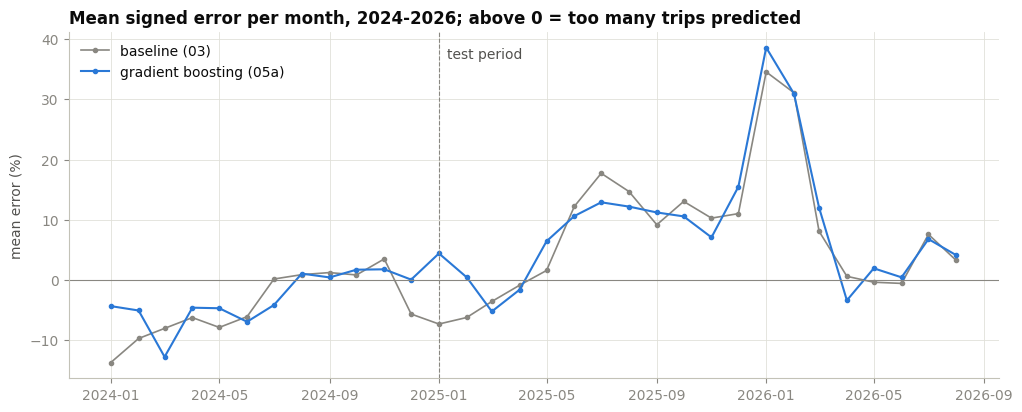

date,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01,2026-01-01,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01
baseline (03),-13.7,-9.7,-8.0,-6.2,-7.8,-6.1,0.2,0.9,1.3,0.9,3.5,-5.6,-7.3,-6.2,-3.5,-0.8,1.6,12.2,17.7,14.7,9.2,13.1,10.3,11.0,34.6,31.1,8.1,0.6,-0.3,-0.5,7.6,3.3
gradient boosting (05a),-4.3,-5.0,-12.7,-4.6,-4.7,-6.9,-4.1,1.1,0.5,1.7,1.8,0.1,4.4,0.5,-5.2,-1.6,6.4,10.6,12.9,12.2,11.2,10.6,7.1,15.5,38.6,30.9,12.0,-3.4,2.0,0.5,6.8,4.1


In [6]:
baseline = joblib.load(MODEL_DIR / "citibike_baseline.joblib")
BASELINE_INPUTS = ["weekday", "month", "holiday", "christmas_week", "tmax_c", "precipitation", "snow_on_ground"]
hold_out = pd.concat([validation, test])
baseline_prediction = pd.Series(np.exp(baseline.predict(hold_out[BASELINE_INPUTS])) * hold_out.level_12m,
                                index=hold_out.index)


def monthly_bias(predicted, days):
    return ((predicted - days.total) / days.total * 100)[days.total > 0].resample("MS").mean()


bias = pd.DataFrame({"baseline (03)": monthly_bias(baseline_prediction, hold_out),
                     "gradient boosting (05a)": monthly_bias(pd.concat(predictions.values()), hold_out)})
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(bias.index, bias["baseline (03)"], color=INK_MUTED, marker="o", markersize=3, linewidth=1.2, label="baseline (03)")
ax.plot(bias.index, bias["gradient boosting (05a)"], color=BLUE, marker="o", markersize=3, linewidth=1.5,
        label="gradient boosting (05a)")
ax.axvline(pd.Timestamp("2025-01-01"), color=INK_MUTED, linewidth=0.8, linestyle="--")
ax.text(pd.Timestamp("2025-01-10"), bias.max().max(), "test period", color=INK_SECONDARY, va="top")
ax.axhline(0, color=INK_MUTED, linewidth=0.8)
ax.set_ylabel("mean error (%)")
ax.set_title("Mean signed error per month, 2024-2026; above 0 = too many trips predicted", loc="left")
ax.legend(loc="upper left", frameon=False)
plt.show()
bias.round(1).T

**Interpretation:** the same pattern as the baseline and the PyCaret blend: too low in the first half of the growth year 2024 (-4% to -13% per month), too high from May 2025 when growth stopped (+6% to +16%), and January and February 2026 +38.6% and +30.9%. Four very different models now make the same monthly errors. The drift belongs to the target (the level of earlier months and the ratio learned in years of growth), not to the model, and the growth feature of section 2 could not fix it inside the training period.

An idea for the next notebooks that **is** possible at prediction time: when a new month is published, the model's error over the last published months is known, so the prediction can be corrected by that recent error (for example the mean of actual / predicted over months *m-4* to *m-2*). Whether that helps must again be tested on the folds.

The ten largest misses of the validation year, as in 03 section 6:

In [7]:
misses = validation.assign(predicted=predictions["validation"].round(0),
                           error_pct=(predictions["validation"] - validation.total) / validation.total * 100)
misses.reindex(misses.error_pct.abs().sort_values(ascending=False).index).head(10)[
    ["total", "predicted", "error_pct", "tmax_c", "precipitation_mm", "snow_depth_mm", "holiday", "weekday"]].round(1)

,total,predicted,error_pct,tmax_c,precipitation_mm,snow_depth_mm,holiday,weekday
date,,,,,,,,
2024-03-09,41934,16350.0,-61.0,9.4,38.9,0.0,0,5
2024-12-25,21436,32857.0,53.3,1.7,0.0,30.0,1,2
2024-12-26,42500,64277.0,51.2,2.2,0.0,30.0,0,3
2024-11-28,26983,40133.0,48.7,9.4,21.8,0.0,1,3
2024-12-24,32673,48415.0,48.2,3.9,2.5,30.0,0,1
2024-04-02,40210,58617.0,45.8,10.6,22.1,0.0,0,1
2024-12-22,31379,18170.0,-42.1,-6.0,0.0,30.0,0,6
2024-11-29,59514,84029.0,41.2,8.3,0.0,0.0,0,4
2024-04-04,96461,57040.0,-40.9,11.7,5.3,0.0,0,3


**Interpretation**

- **Rain timing:** Saturday 9 March 2024 had 38.9 mm of rain and still 41,934 trips; the model predicted 16,350 (-61%). Saturday 23 March (93 mm) was also 39% busier than predicted. As in 03, a daily total cannot say whether the rain fell in a few hours or all day.
- **The big holidays are still missed:** 24, 25 and 26 December are 48-53% too high (with 30 mm of old snow on the ground), Thanksgiving 49% and the day after 41% too high. The trees could not use the big-holiday flags (section 2); a model that can is the job of 05b.
- Compared with the baseline's list (03 section 6), the summer storms and the old-snow days are gone from the top ten: the millimetres of rain and snow depth help there.

## 6. What does the model look at?

**Permutation importance** on the validation year: shuffle one column, so that its link with the target is broken, and measure how much the MAPE in trips gets worse (10 repeats). Unlike the impurity-based importance of 04, it is measured on data the model has not seen and does not favour columns with many split points.

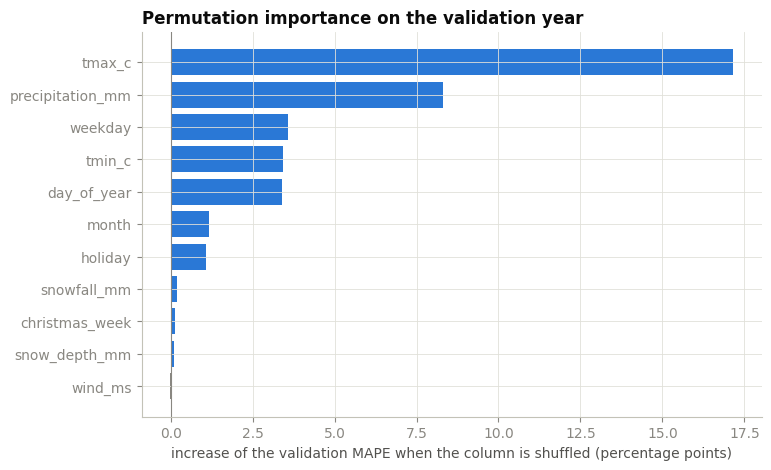

,tmax_c,precipitation_mm,weekday,tmin_c,day_of_year,month,holiday,snowfall_mm,christmas_week,snow_depth_mm,wind_ms
MAPE increase,17.17,8.32,3.58,3.44,3.39,1.16,1.08,0.19,0.14,0.11,-0.03


In [8]:
importance = permutation_importance(model, validation[FEATURES], np.log(validation.demand_ratio), scoring=mape_scorer,
                                    n_repeats=10, random_state=RANDOM_STATE)
importance = pd.Series(importance.importances_mean, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance.index, importance.values, color=[BLUE if value > 0 else INK_MUTED for value in importance])
ax.axvline(0, color=INK_MUTED, linewidth=0.8)
ax.set_xlabel("increase of the validation MAPE when the column is shuffled (percentage points)")
ax.set_title("Permutation importance on the validation year", loc="left")
plt.show()
importance.sort_values(ascending=False).round(2).to_frame("MAPE increase").T

**Interpretation**

- **Maximum temperature** is by far the most important column: shuffling it makes the validation MAPE 17.2 points worse. Then **precipitation** (8.3), weekday (3.6), minimum temperature (3.4) and day of the year (3.4); month (1.2) and holiday (1.1) add a little on top of the day of the year.
- Snowfall, Christmas week and snow depth score almost 0. That is a property of the **validation year**: 2024 had little snow, so shuffling the snow columns changes little. In a snowy winter they matter (03 found -34% for snow on the ground).
- **Wind scores 0** (-0.03): the model does not use it. Dropping it would make the API one input simpler; we keep it for now because removing it is a new choice that should be made on the folds, not on the validation year.

## 7. Saving the model and the metrics

The model is saved with `joblib`. It needs no preprocessing pipeline: it takes the input columns as they are in the daily files (with `NaN` allowed for the wind) and returns the log ratio. The JSON file describes the input and the output for the API. Compared with the baseline, the API needs more of the forecast: also the minimum temperature, the snowfall and the wind.

In [9]:
joblib.dump(model, MODEL_PATH, compress=3)
size_kb = MODEL_PATH.stat().st_size / 1024
reloaded = joblib.load(MODEL_PATH)
assert np.allclose(reloaded.predict(test[FEATURES]), model.predict(test[FEATURES]))
description = {
    "model": "citibike_gradient_boosting", "notebook": NOTEBOOK, "estimator": "HistGradientBoostingRegressor",
    "input_columns": FEATURES, "categorical_columns": ["weekday", "month"], "missing_values_allowed": ["wind_ms"],
    "output": "log(demand_ratio); predicted trips = exp(output) * level_12m",
    "level_12m": DATASET["level_definition"],
    "hyperparameters": {key: (float(value) if isinstance(value, (np.floating, float)) else value)
                        for key, value in model.get_params().items()
                        if key in ["learning_rate", "max_iter", "max_leaf_nodes", "min_samples_leaf",
                                   "l2_regularization", "max_features"]},
    "validation": {key: round(float(value), 2) for key, value in results[0].items() if key in ("mae", "mape", "bias_pct")},
}
with open(MODEL_PATH.with_suffix(".json"), "w", encoding="utf-8") as file:
    json.dump(description, file, indent=2)
print(f"saved {MODEL_PATH} ({size_kb:.0f} KB) and {MODEL_PATH.with_suffix('.json').name}")

metrics = pd.read_csv(METRICS_PATH)
metrics = pd.concat([metrics[metrics.notebook != NOTEBOOK], pd.DataFrame(results)], ignore_index=True)
metrics.to_csv(METRICS_PATH, index=False)
metrics.drop(columns="notebook").round(1)

saved models\citibike_gradient_boosting.joblib (552 KB) and citibike_gradient_boosting.json


,model,split,days,mae,rmse,mape,median_ape,within_20pct,bias_pct
0,Huber regression (05b),validation,366,11645.3,15293.6,10.8,8.7,88.3,-2.7
1,Huber regression (05b),test,607,15837.4,20535.3,15.7,11.2,77.9,9.4
2,ensemble 05a + 05b (05c),validation,366,9712.1,12667.1,9.3,6.8,90.2,-3.1
3,ensemble 05a + 05b (05c),test,607,14363.4,18112.8,14.4,10.2,81.4,8.8
4,seasonal naive,validation,366,17755.7,24079.1,22.2,10.9,71.9,5.2
5,linear regression (baseline),validation,366,12787.6,16670.3,12.4,9.7,82.2,-4.2
6,seasonal naive,test,607,24128.1,32296.4,38.0,14.7,61.9,31.6
7,linear regression (baseline),test,607,17205.6,22336.1,17.4,11.9,73.6,7.8
8,PyCaret blend gbr + rf + lightgbm,validation,366,9657.7,12700.3,9.5,6.3,88.5,-3.1
9,PyCaret blend gbr + rf + lightgbm,test,607,13806.2,17529.1,14.6,9.8,80.9,8.6


## 8. Conclusion and next steps

- **Model:** `HistGradientBoostingRegressor` on the extended columns of 02 (calendar, maximum and minimum temperature, rain, snowfall and snow depth in mm, wind, day of the year), tuned with a random search on the yearly folds. Validation MAPE 9.6% and MAE 9,500 trips (the lowest so far), test MAPE 15.1% and MAE 14,578. Saved as `models/citibike_gradient_boosting.joblib` (552 KB) with its JSON description.
- **What worked:** the extended weather columns. **What did not:** big-holiday flags (too rare for trees), a recent-growth feature (noisy) and weighting recent years (no gain on the folds). Tuning gained only 0.2 points on the folds.
- **A lesson for the protocol:** a search optimises exactly the score it gets. Scored on the log scale it chose a model that was worse in trips, so the protocol now scores the MAPE in trips (03 section 3).
- **Open problems:** the drift with the growth of the system (test bias +8.8%) and the big holidays.

**Next steps:** `05b`, a robust linear model (Huber) that can use the big-holiday flags (a prototype scored a fold MAPE of about 15.7% and a validation MAPE of about 10.2%); then an ensemble of the two families, the recent-error correction of section 5, `06` (AWS) and `07` (comparison).